### 🎯 Objective
Build a model to predict whether a loan application will be approved or not.

### 💼 Business Goal
- Minimize loan default risk  
- Improve decision-making efficiency  
- Automate approval process using data-driven insights  

In [ ]:
# checking Python version
print(f"Python --version: {__import__('sys').version}")

Python --version: 3.11.0 (main, Oct 24 2022, 18:26:48) [MSC v.1933 64 bit (AMD64)]


In [ ]:
# Importing necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Load the dataset
df = pd.read_csv("loan_data.csv")

### 📁 Dataset Summary
- Contains applicant financial and personal details  
- Includes features like income, age, credit score, loan amount  

### 🎯 Target Variable
- `loan_status`  
  - 1 → Approved  
  - 0 → Rejected  

### 📏 Shape
- Rows: 45000
- Columns: 14 

In [ ]:
# preview of the dataset
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [ ]:
# dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  str    
 2   person_education                45000 non-null  str    
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  str    
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  str    
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  45000 non-n

In [ ]:
df.shape

(45000, 14)

In [ ]:
#Statistical summary of the dataset
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


### 🔍 Steps Performed
- Handled missing values  
- Removed/treated outliers  
- Filtered unrealistic age values  

### ✅ Result
Clean and consistent dataset ready for analysis and modeling  

In [ ]:
# checking for missing values
df.isnull().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

In [ ]:
# checking for duplicate values
df.duplicated().sum()

np.int64(0)

### Handling Outlier in Age

In [ ]:
df['person_age'].min()

np.float64(20.0)

In [ ]:
df['person_age'].max()

np.float64(144.0)

In [ ]:
df = df[(df['person_age'] >= 18) & (df['person_age'] <= 100)]

### 📈 Univariate Analysis
- Distribution of income, age, loan amount  
- Class balance of loan approval  

### 🔗 Bivariate Analysis
- Relationship between income & approval  
- Credit score vs loan status  
- Loan amount vs approval  
 

Text(0.5, 1.0, 'Loan Status Distribution')

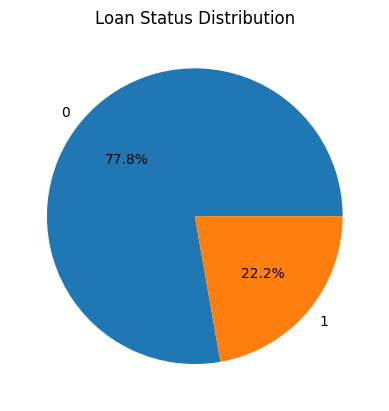

In [ ]:
#pie chart for loan status distribution

counts = df['loan_status'].value_counts()

plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
plt.title("Loan Status Distribution")

Text(0.5, 1.0, 'person Gender Distribution')

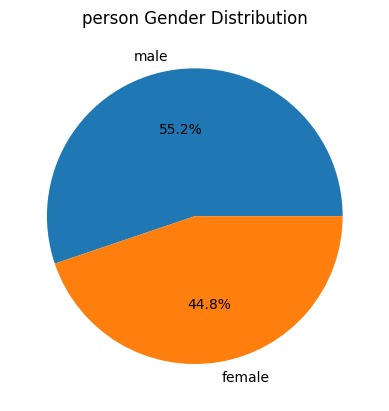

In [ ]:
# Visualize the distribution of person gender

#pie chart for person gender distribution
counts = df['person_gender'].value_counts()

plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
plt.title("person Gender Distribution")

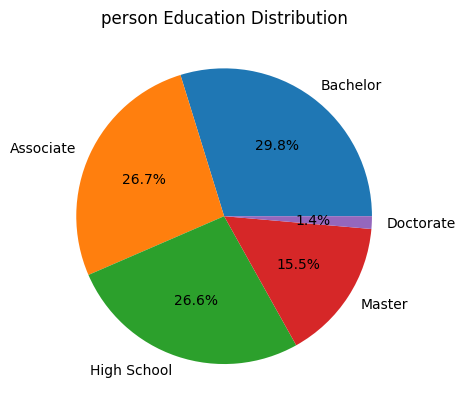

In [ ]:
#pie chart for person education distribution

counts = df['person_education'].value_counts()

plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
plt.title("person Education Distribution")
plt.show()

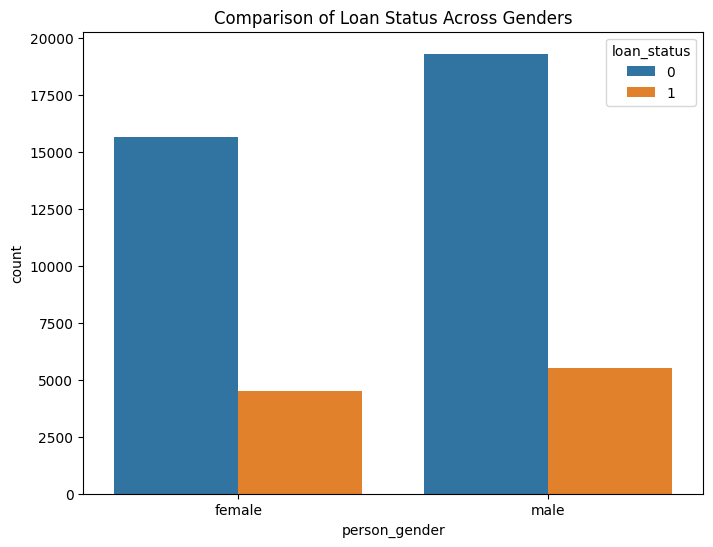

In [ ]:
# bar plot for comparison of loan status across genders

plt.figure(figsize=(8,6))

sns.countplot(x='person_gender', hue='loan_status', data=df)
plt.title("Comparison of Loan Status Across Genders")
plt.xlabel("person_gender")
plt.ylabel("count")
plt.show()

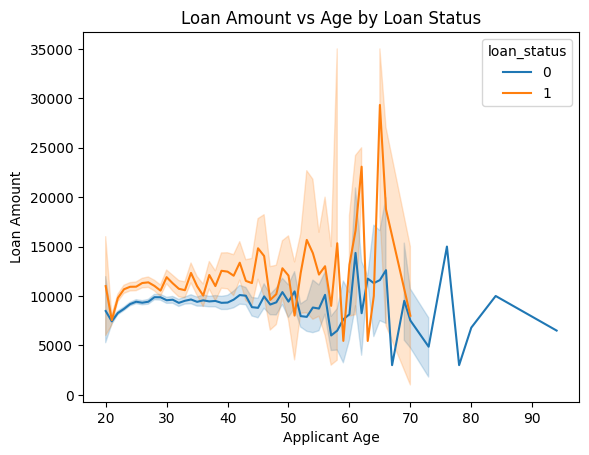

In [ ]:
# line plot for loan amount vs age by loan status

sns.lineplot(
    x='person_age',
    y='loan_amnt',
    hue='loan_status',
    data=df
)
plt.title("Loan Amount vs Age by Loan Status")
plt.xlabel("Applicant Age")
plt.ylabel("Loan Amount")
plt.show()

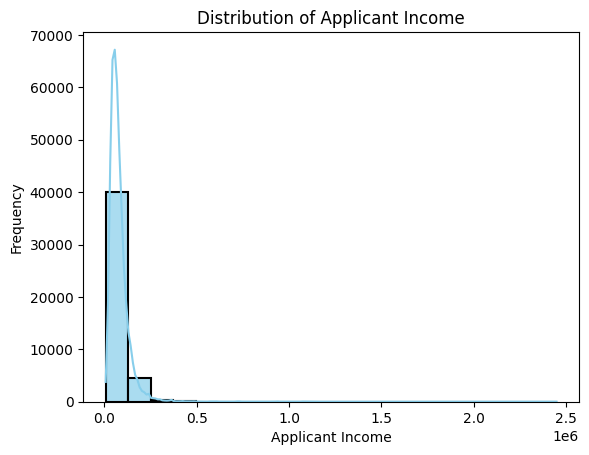

In [ ]:
# histogram for distribution of applicant income

sns.histplot(df['person_income'],
             color='skyblue',
             edgecolor='black',
             alpha=0.7,
             linewidth=1.5,
             bins=20,
             kde=True)
plt.title("Distribution of Applicant Income")
plt.xlabel("Applicant Income")
plt.ylabel("Frequency")
plt.show()

In [ ]:
print(df['person_income'].describe())

count    4.499300e+04
mean     7.990845e+04
std      6.332213e+04
min      8.000000e+03
25%      4.719500e+04
50%      6.704600e+04
75%      9.577800e+04
max      2.448661e+06
Name: person_income, dtype: float64


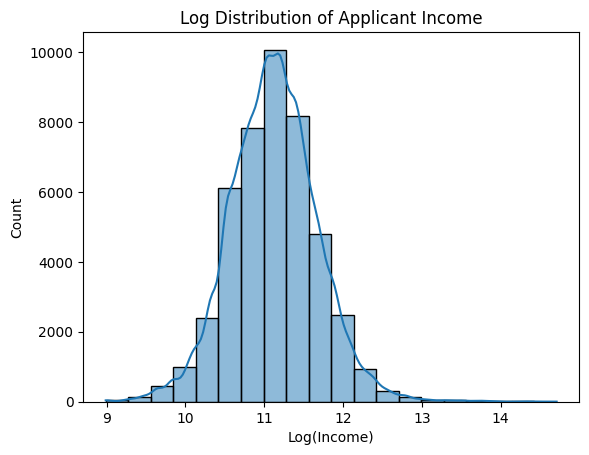

In [ ]:
# Log transformation of applicant income to handle skewness

sns.histplot(np.log1p(df['person_income']), bins=20, kde=True)
plt.title("Log Distribution of Applicant Income")
plt.xlabel("Log(Income)")
plt.show()

<Axes: xlabel='person_home_ownership', ylabel='loan_amnt'>

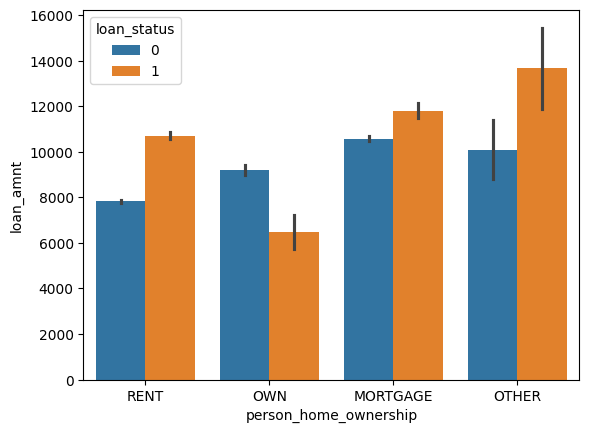

In [ ]:
# bar plot for comparison of loan amount by home ownership and loan status

sns.barplot(
    x='person_home_ownership',
    y='loan_amnt',
    hue='loan_status',
    data=df
)

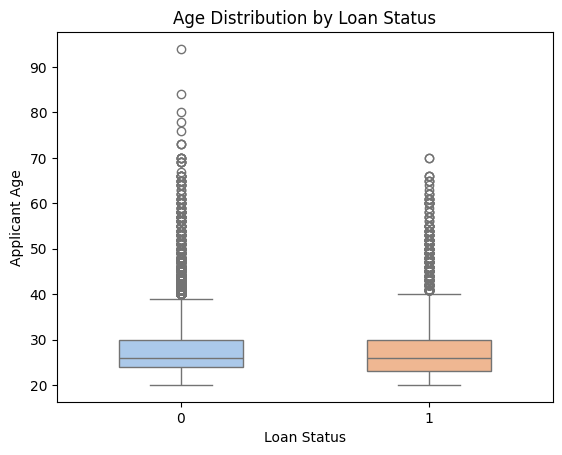

In [ ]:
# box plot for age distribution by loan status

sns.boxplot(
    x='loan_status',
    y='person_age',
    data=df,
    palette='pastel',
    width=0.5,
    orient='v',)
plt.title("Age Distribution by Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Applicant Age")
plt.show()

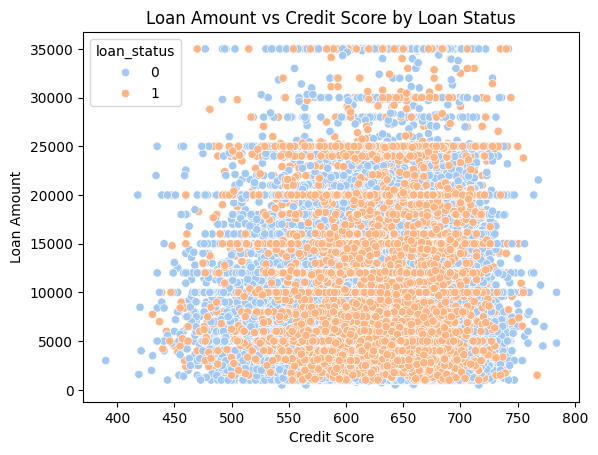

In [ ]:
sns.scatterplot(
    x='credit_score',
    y='loan_amnt',
    hue='loan_status',
    data=df,
    palette='pastel'
)

plt.title("Loan Amount vs Credit Score by Loan Status")
plt.xlabel("Credit Score")
plt.ylabel("Loan Amount")
plt.show()

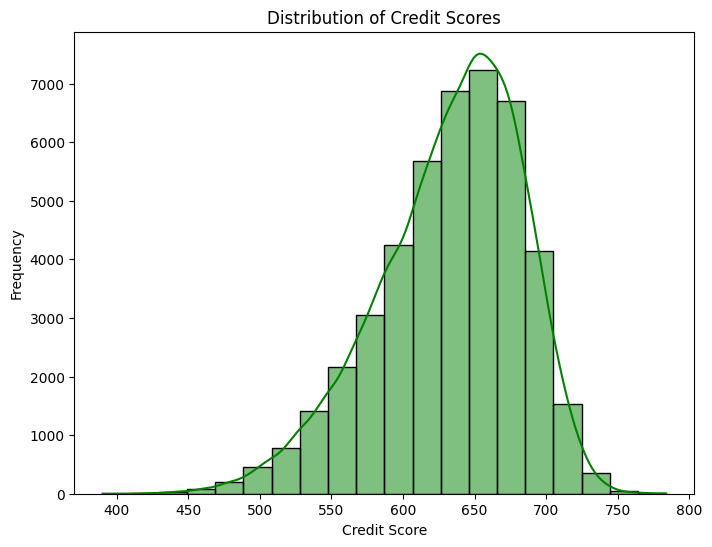

In [ ]:
plt.figure(figsize=(8,6))

sns.histplot(df['credit_score'], bins=20, kde=True,
             color='green', edgecolor='black')

plt.title("Distribution of Credit Scores")
plt.xlabel("Credit Score")
plt.ylabel("Frequency")
plt.show()

<Axes: xlabel='loan_status', ylabel='credit_score'>

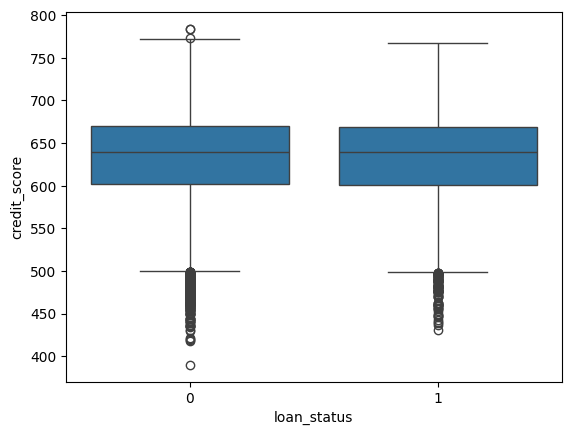

In [ ]:
sns.boxplot(x='loan_status', y='credit_score', data=df)

In [ ]:
home_ownership_approval_rate = df.groupby('person_home_ownership')['loan_status'].mean()

df['home_ownership_approval_rate'] = df['person_home_ownership'].map(home_ownership_approval_rate)

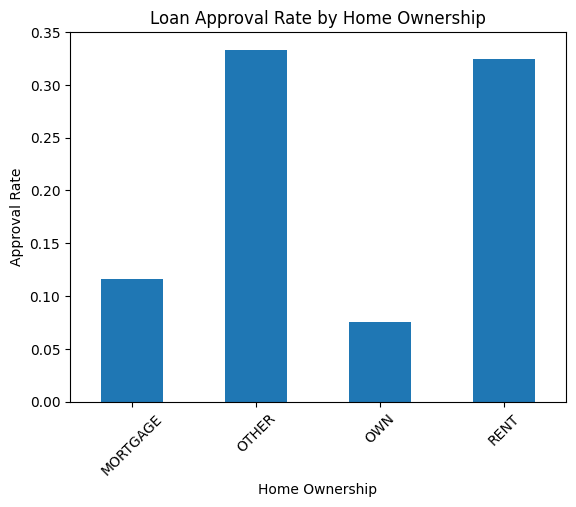

In [ ]:
home_ownership_approval_rate.plot(kind='bar')

plt.title("Loan Approval Rate by Home Ownership")
plt.xlabel("Home Ownership")
plt.ylabel("Approval Rate")
plt.xticks(rotation=45)
plt.show()

In [ ]:
df['loan_income_ratio'] = df['loan_amnt'] / df['person_income']

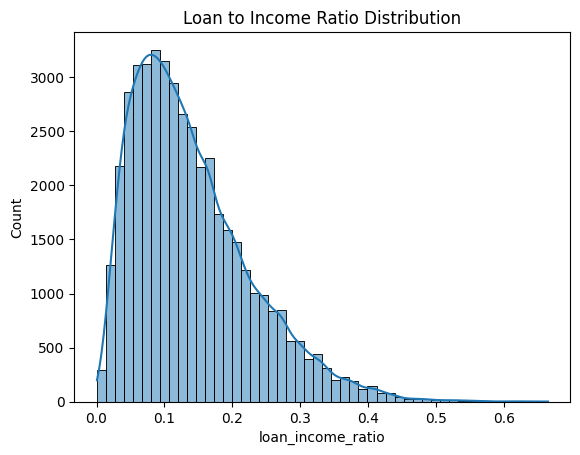

In [ ]:
plt.figure()
sns.histplot(df['loan_income_ratio'], bins=50, kde=True)
plt.title('Loan to Income Ratio Distribution')
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
le = LabelEncoder()


In [ ]:
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier()
}

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    print(f"{name}: Mean={scores.mean():.4f}, Std={scores.std():.4f}")

Logistic Regression: Mean=0.8314, Std=0.0091
Random Forest: Mean=0.9253, Std=0.0066
Decision Tree: Mean=0.8948, Std=0.0078


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5, scoring='accuracy')
grid.fit(X, y)

print("Best Params:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best Score: 0.925388798108288


In [ ]:
model = RandomForestClassifier(n_estimators=200, max_depth=None, min_samples_split=2)

In [ ]:
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
print(f"Accuracy of model is: {accuracy_score(y_test, y_pred)}")

Accuracy of model is: 0.9293254806089566


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.98      0.96      7002
           1       0.90      0.76      0.83      1997

    accuracy                           0.93      8999
   macro avg       0.92      0.87      0.89      8999
weighted avg       0.93      0.93      0.93      8999



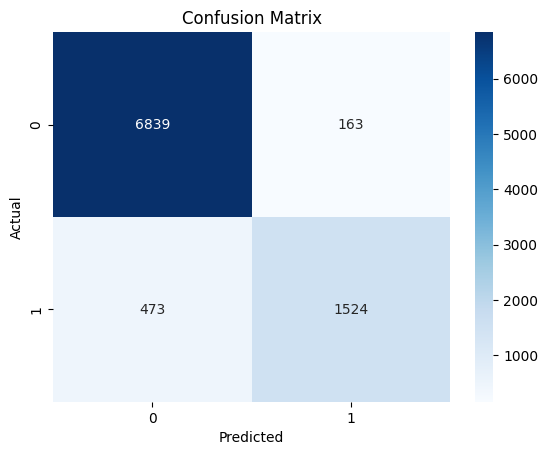

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()